## Imports

In [2]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture

## Task 1

### Reading the Data (Copied from the first Exercise)

In [4]:
# Reading in the data and subsequentially cutting out a redshift range and diving between red and blue galaxies according to color.
data = pandas.read_csv('../sdss_cutout.csv')
z = data['Z'].values
# Changed to a thinner slice
z_mask_thin = (z > 0.095) & (z < 0.105)
z_mask_full = (z > 0.08) & (z < 0.12)
data_thin = data[z_mask_thin].reset_index(drop=True)
data_full = data[z_mask_full].reset_index(drop=True)

ra_thin = data_thin['RA'].values
dec_thin = data_thin['DEC'].values

ra_full = data_full['RA'].values
dec_full = data_full['DEC'].values

# Computing the color of the galaxies and dividing them into red and blue populations according to the color cut at 2.3.
u_mag = data_thin['phot_u'].values
r_mag = data_thin['phot_r'].values
color = u_mag - r_mag
red_gal = data_thin[color > 2.3].reset_index(drop=True)
blue_gal = data_thin[color <= 2.3].reset_index(drop=True)

# Reading out the RA and DEC values from the two populations.
red_gal_ra = red_gal['RA'].values
red_gal_dec = red_gal['DEC'].values

blue_gal_ra = blue_gal['RA'].values
blue_gal_dec = blue_gal['DEC'].values

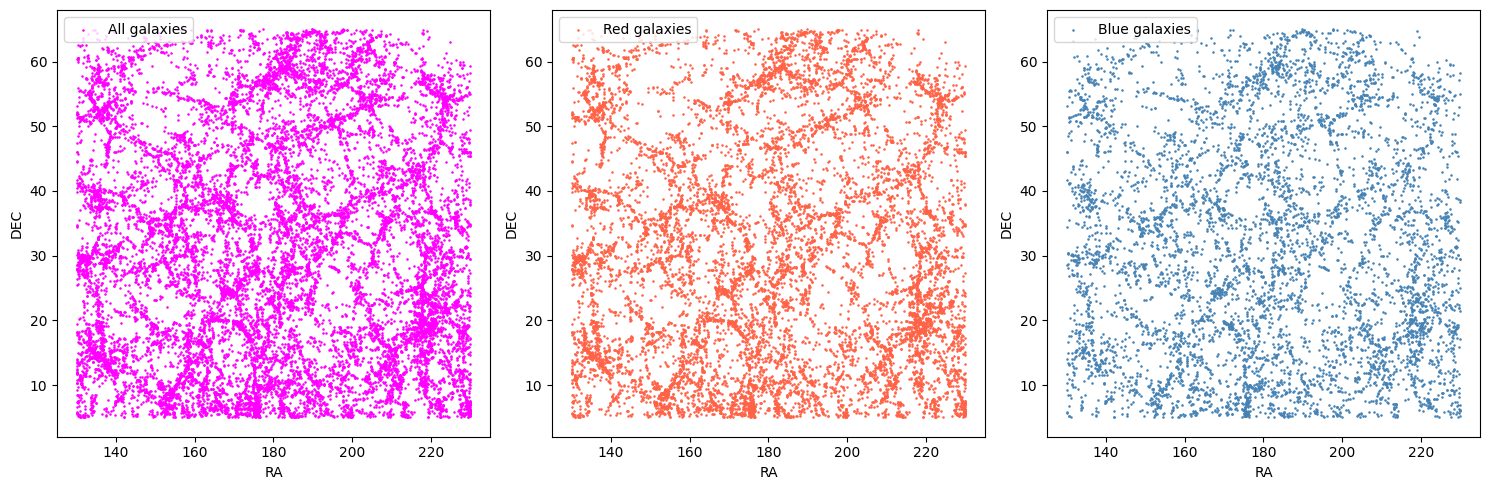

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(ra_thin, dec_thin, s=0.7, color='magenta', label='All galaxies')
axes[0].set_xlabel('RA')
axes[0].set_ylabel('DEC')
axes[1].scatter(red_gal_ra, red_gal_dec, s=0.7, color='tomato', label='Red galaxies')
axes[1].set_xlabel('RA')
axes[1].set_ylabel('DEC')
axes[2].scatter(blue_gal_ra, blue_gal_dec, s=0.7, color='steelblue', label='Blue galaxies')
axes[2].set_xlabel('RA')
axes[2].set_ylabel('DEC')
for ax in axes:
    ax.legend()
plt.tight_layout()

plt.show()

## Task 2

In [40]:
# Creating space vectors
#full_ra_g = np.linspace(full_ra.min(), full_ra.max(), len(full_ra))
#full_dec_g = np.linspace(full_dec.min(), full_dec.max(), len(full_dec))
#x_g, y_g = np.meshgrid(full_ra_g, full_dec_g)

Xgrid = np.column_stack([ra_full, dec_full])

bandwidths = np.geomspace(0.05, 2.0, 30)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
    {'bandwidth': bandwidths}, cv=None, n_jobs=-1)
grid.fit(Xgrid) # Xdata has shape (N,2) for 2D

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KernelDensity()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bandwidth': array([0.05 ..., 2. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter

In [44]:
print(grid.cv_results_)
h_opt = grid.best_params_['bandwidth']
print(f'Optimal bandwidth: {h_opt:.3f}')

sigma_hat  = np.sqrt(np.std(ra_full) * np.std(dec_full))   # geometric mean
h_silverman = (4/4)**(1/6) * sigma_hat * len(Xgrid)**(-1/6)

cv_scores  = grid.cv_results_['mean_test_score']
cv_std     = grid.cv_results_['std_test_score']

{'mean_fit_time': array([0.02077146, 0.02033491, 0.02097974, 0.02076159, 0.02064176,
       0.02026653, 0.02155404, 0.02033195, 0.02060204, 0.020258  ,
       0.01983032, 0.02016025, 0.02003369, 0.01999321, 0.01984038,
       0.02014928, 0.01981254, 0.01982265, 0.0196476 , 0.02087131,
       0.01987133, 0.01986923, 0.02839251, 0.0216413 , 0.01974578,
       0.01979914, 0.02072992, 0.01999879, 0.02050667, 0.02041798]), 'std_fit_time': array([0.00043967, 0.00027028, 0.00086843, 0.00192131, 0.00129028,
       0.00097609, 0.00241022, 0.00098119, 0.00132106, 0.00090853,
       0.00015777, 0.00068437, 0.00043961, 0.00040921, 0.00048416,
       0.00098347, 0.00014766, 0.00031822, 0.00014741, 0.00097258,
       0.00031836, 0.00063526, 0.01620017, 0.00199456, 0.00029174,
       0.00029841, 0.00071537, 0.00087783, 0.00094819, 0.00051891]), 'mean_score_time': array([ 6.52275438,  7.39728065,  8.6246202 ,  9.90941343, 11.39284225,
       13.08250895, 14.44596543, 16.3026576 , 18.27546501, 19.67881

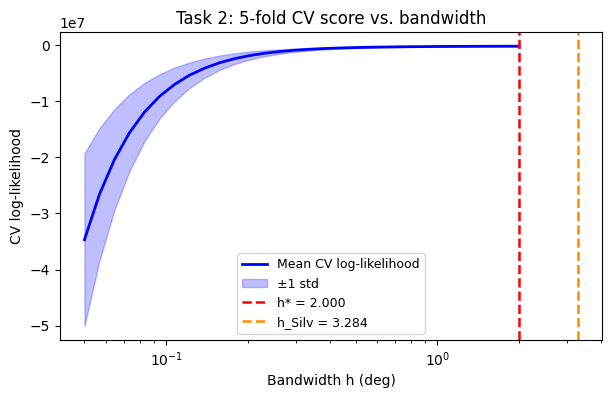

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(bandwidths, cv_scores, 'b-', lw=2, label='Mean CV log-likelihood')
ax.fill_between(bandwidths, cv_scores-cv_std, cv_scores+cv_std,
                alpha=0.25, color='blue', label='±1 std')
ax.axvline(h_opt,        color='red',        ls='--', lw=1.8, label=f'h* = {h_opt:.3f}')
ax.axvline(h_silverman,  color='darkorange', ls='--', lw=1.8, label=f'h_Silv = {h_silverman:.3f}')
ax.set_xlabel("Bandwidth h (deg)"); ax.set_ylabel("CV log-likelihood")
ax.set_title("Task 2: 5-fold CV score vs. bandwidth"); ax.legend(fontsize=9)

## Task 3

BIC scores: ['K=1:129388', 'K=2:111308', 'K=3:111702', 'K=4:104772', 'K=5:102939', 'K=6:102957']
  DELTA_BIC: ['K=2:18079', 'K=3:-393', 'K=4:6930', 'K=5:1833', 'K=6:-18']


Text(0.5, 1.0, 'Task 3: BIC score vs. number of components k')

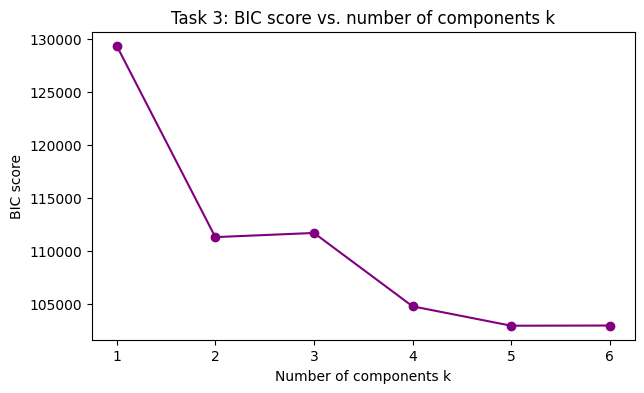

In [ ]:
u_mag = data_full['phot_u'].values
r_mag = data_full['phot_r'].values
color = u_mag - r_mag

bic_scores = []
for k in range(1, 7):
    gm = GaussianMixture(n_components=k, n_init=5).fit(color[:,np.newaxis])
    bic_scores.append(gm.bic(color[:,np.newaxis]))
# soft membership for chosen model:

BIC scores: ['K=1:129388', 'K=2:111308', 'K=3:111702', 'K=4:104772', 'K=5:102939', 'K=6:102957']
DELTA_BIC: ['K=2:18079', 'K=3:-393', 'K=4:6930', 'K=5:1833', 'K=6:-18']


Text(0.5, 1.0, 'Task 3: BIC score vs. number of components k')

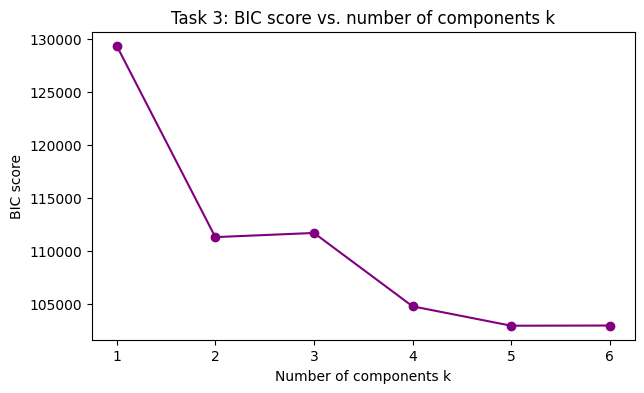

In [16]:
delta_bic = [bic_scores[k-1] - bic_scores[k] for k in range(1, 6)]
print("BIC scores:", [f"K={k}:{b:.0f}" for k,b in enumerate(bic_scores,1)])
print("DELTA_BIC:", [f"K={k}:{d:.0f}" for k,d in enumerate(delta_bic,2)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 7), bic_scores, 'o-', color='purple')
ax.set_xlabel("Number of components k"); ax.set_ylabel("BIC score")
ax.set_title("Task 3: BIC score vs. number of components k")

